# CSI_6_ARI — CW2: End-to-End ML Pipeline & AI Maintenance Agent
**Student ID:** 4438487 | **RI:** T2-M1-S1  
**Models:** Support Vector Machine · Ridge Classifier · Random Forest Classifier  
**Dataset:** SMI_Train_4438487.csv | SMI_Test_800.csv | SMI_Operational_200.csv

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# Operational cost constants (from CW2 spec)
COST_FP = 10    # False positive: unnecessary inspection
COST_FN = 500   # False negative: missed failure
RANDOM_STATE = 42

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading & Exploratory Data Analysis

In [2]:
# Load datasets
train_raw = pd.read_csv('/content/SMI_Train_4438487.csv')
test_raw  = pd.read_csv('/content/SMI_Test_800.csv')
op_raw    = pd.read_csv('/content/SMI_Operational_200.csv')

print(f'Training set:     {train_raw.shape[0]:,} rows × {train_raw.shape[1]} cols')
print(f'Test set:         {test_raw.shape[0]:,} rows × {test_raw.shape[1]} cols')
print(f'Operational feed: {op_raw.shape[0]:,} rows × {op_raw.shape[1]} cols')

Training set:     8,000 rows × 171 cols
Test set:         800 rows × 171 cols
Operational feed: 200 rows × 170 cols


In [3]:
# Class distribution
class_counts = train_raw['class'].value_counts()
print('Training class distribution:')
print(class_counts)
imbalance_ratio = class_counts['neg'] / class_counts['pos']
print(f'\nImbalance ratio (neg:pos): {imbalance_ratio:.1f}:1')
print(f'Positive class prevalence: {class_counts["pos"]/len(train_raw)*100:.2f}%')

Training class distribution:
class
neg    7867
pos     133
Name: count, dtype: int64

Imbalance ratio (neg:pos): 59.2:1
Positive class prevalence: 1.66%


In [4]:
# Missing value analysis (sensors use string 'na')
X_train_raw = train_raw.drop(columns=['class']).replace('na', np.nan)
X_train_raw = X_train_raw.apply(pd.to_numeric, errors='coerce')

miss_per_feature = X_train_raw.isnull().mean() * 100
total_missing_pct = X_train_raw.isnull().sum().sum() / (X_train_raw.shape[0] * X_train_raw.shape[1]) * 100
high_miss = (miss_per_feature > 50).sum()
print(f'Total missing values: {total_missing_pct:.2f}%')
print(f'Features with >50% missing: {high_miss}')
print(f'Features with any missing:  {(miss_per_feature > 0).sum()}')
print(f'\nMissing rate distribution (quartiles):')
print(miss_per_feature[miss_per_feature > 0].describe().round(2))

Total missing values: 8.44%
Features with >50% missing: 8
Features with any missing:  169

Missing rate distribution (quartiles):
count    169.00
mean       8.49
std       16.99
min        0.32
25%        1.27
50%        1.31
75%        4.88
max       82.28
dtype: float64


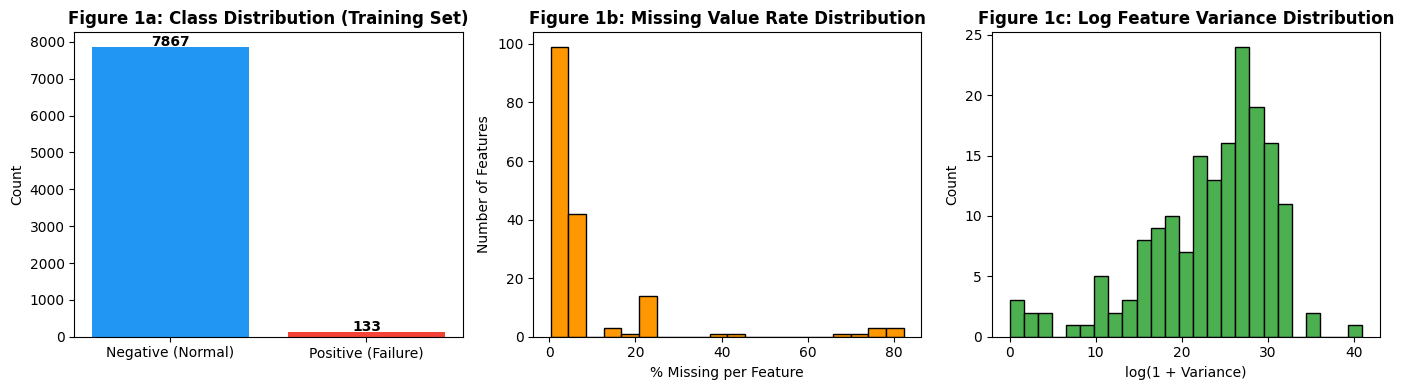

Figure 1 saved.


In [5]:
# EDA Visualisation 1: Class imbalance
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Class bar chart
colors = ['#2196F3', '#F44336']
axes[0].bar(['Negative (Normal)', 'Positive (Failure)'],
            [class_counts['neg'], class_counts['pos']], color=colors)
axes[0].set_title('Figure 1a: Class Distribution (Training Set)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([class_counts['neg'], class_counts['pos']]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Missing values histogram
axes[1].hist(miss_per_feature[miss_per_feature > 0], bins=20, color='#FF9800', edgecolor='black')
axes[1].set_title('Figure 1b: Missing Value Rate Distribution', fontweight='bold')
axes[1].set_xlabel('% Missing per Feature')
axes[1].set_ylabel('Number of Features')

# Feature variance distribution
feat_var = X_train_raw.var()
axes[2].hist(np.log1p(feat_var), bins=25, color='#4CAF50', edgecolor='black')
axes[2].set_title('Figure 1c: Log Feature Variance Distribution', fontweight='bold')
axes[2].set_xlabel('log(1 + Variance)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 2. Preprocessing Pipeline
All transformations are fitted on training data ONLY to prevent data leakage.

In [6]:
def load_and_prepare(df, has_label=True):
    """Convert raw DataFrame to numeric X and binary y."""
    df = df.copy()
    if has_label:
        y = (df['class'] == 'pos').astype(int)
        X = df.drop(columns=['class'])
    else:
        y = None
        X = df.copy()
    X = X.replace('na', np.nan).apply(pd.to_numeric, errors='coerce')
    return X, y

X_train_full, y_train_full = load_and_prepare(train_raw)
X_test,       y_test       = load_and_prepare(test_raw)
X_op,         _            = load_and_prepare(op_raw, has_label=False)

# Stratified 80/20 train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)
print(f'Training subset:   {X_tr.shape[0]:,} rows (pos={y_tr.sum()})')
print(f'Validation subset: {X_val.shape[0]:,} rows (pos={y_val.sum()})')

# Step 1: Median imputation (fitted on training only)
imputer = SimpleImputer(strategy='median')
X_tr_imp  = imputer.fit_transform(X_tr)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)
X_op_imp  = imputer.transform(X_op)

# Step 2: Standard scaling (fitted on training only)
scaler = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr_imp)
X_val_sc  = scaler.transform(X_val_imp)
X_test_sc = scaler.transform(X_test_imp)
X_op_sc   = scaler.transform(X_op_imp)

print('\nPreprocessing pipeline fitted on training data only. No leakage.')

Training subset:   6,400 rows (pos=106)
Validation subset: 1,600 rows (pos=27)

Preprocessing pipeline fitted on training data only. No leakage.


## 3. Helper Functions: Cost-Aware Evaluation

In [7]:
def compute_cost(y_true, y_pred):
    """Compute operational cost given asymmetric cost structure."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * COST_FP + fn * COST_FN
    return total_cost, int(tp), int(fp), int(fn), int(tn)

def find_cost_optimal_threshold(y_true, y_proba, n_steps=300):
    """Sweep thresholds and return the one minimising expected cost."""
    best_cost, best_thresh = np.inf, 0.5
    for t in np.linspace(0.01, 0.99, n_steps):
        y_pred = (y_proba >= t).astype(int)
        if y_pred.sum() == 0:
            continue
        cost, *_ = compute_cost(y_true, y_pred)
        if cost < best_cost:
            best_cost, best_thresh = cost, t
    return float(best_thresh), int(best_cost)

def full_evaluate(name, y_true, y_proba, thresh):
    """Return full metrics dict for a model at given threshold."""
    y_pred = (y_proba >= thresh).astype(int)
    cost, tp, fp, fn, tn = compute_cost(y_true, y_pred)
    return {
        'model': name,
        'threshold': round(thresh, 3),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'auc_roc':   round(roc_auc_score(y_true, y_proba), 4),
        'pr_auc':    round(average_precision_score(y_true, y_proba), 4),
        'total_cost': cost,
        'fn_cost': fn * COST_FN,
        'fp_cost': fp * COST_FP,
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Helper functions defined.')

Helper functions defined.


## 4. Model 1: Support Vector Machine (SVM)

In [8]:
print('Training SVM with GridSearchCV (5-fold stratified CV)...')
svm_params = {'C': [0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto']}
svm_base   = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm_gs     = GridSearchCV(svm_base, svm_params, cv=cv, scoring='average_precision', n_jobs=-1)
svm_gs.fit(X_tr_sc, y_tr)

svm_best = svm_gs.best_estimator_
print(f'Best params: {svm_gs.best_params_}')

# Threshold selection on VALIDATION set only
svm_val_proba  = svm_best.predict_proba(X_val_sc)[:, 1]
svm_thresh, svm_val_cost = find_cost_optimal_threshold(y_val, svm_val_proba)
print(f'Cost-optimal threshold (val): {svm_thresh:.3f}  |  Val cost: £{svm_val_cost:,}')

# Test set evaluation
svm_test_proba = svm_best.predict_proba(X_test_sc)[:, 1]
svm_metrics    = full_evaluate('SVM', y_test, svm_test_proba, svm_thresh)
print(f"\nTest AUC-ROC: {svm_metrics['auc_roc']}  PR-AUC: {svm_metrics['pr_auc']}")
print(f"Test Recall: {svm_metrics['recall']}  Precision: {svm_metrics['precision']}  F1: {svm_metrics['f1']}")
print(f"Test Cost:   £{svm_metrics['total_cost']:,} (FP=£{svm_metrics['fp_cost']}, FN=£{svm_metrics['fn_cost']})")

Training SVM with GridSearchCV (5-fold stratified CV)...
Best params: {'C': 0.1, 'gamma': 'auto'}
Cost-optimal threshold (val): 0.135  |  Val cost: £1,430

Test AUC-ROC: 0.9903  PR-AUC: 0.9568
Test Recall: 0.9375  Precision: 0.8721  F1: 0.9036
Test Cost:   £5,220 (FP=£220, FN=£5000)


## 5. Model 2: Ridge Classifier (Calibrated)

In [9]:
print('Training Ridge Classifier with isotonic calibration...')
best_alpha, best_auprc, best_ridge = None, -1, None
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    rc = RidgeClassifier(alpha=alpha, class_weight='balanced')
    rc_cal = CalibratedClassifierCV(rc, cv=cv, method='isotonic')
    rc_cal.fit(X_tr_sc, y_tr)
    proba = rc_cal.predict_proba(X_val_sc)[:, 1]
    auprc = average_precision_score(y_val, proba)
    if auprc > best_auprc:
        best_auprc, best_alpha, best_ridge = auprc, alpha, rc_cal

print(f'Best alpha: {best_alpha}  |  Val PR-AUC: {best_auprc:.4f}')

ridge_val_proba = best_ridge.predict_proba(X_val_sc)[:, 1]
ridge_thresh, ridge_val_cost = find_cost_optimal_threshold(y_val, ridge_val_proba)
print(f'Cost-optimal threshold (val): {ridge_thresh:.3f}  |  Val cost: £{ridge_val_cost:,}')

ridge_test_proba = best_ridge.predict_proba(X_test_sc)[:, 1]
ridge_metrics    = full_evaluate('Ridge Classifier', y_test, ridge_test_proba, ridge_thresh)
print(f"\nTest AUC-ROC: {ridge_metrics['auc_roc']}  PR-AUC: {ridge_metrics['pr_auc']}")
print(f"Test Recall: {ridge_metrics['recall']}  Precision: {ridge_metrics['precision']}  F1: {ridge_metrics['f1']}")
print(f"Test Cost:   £{ridge_metrics['total_cost']:,} (FP=£{ridge_metrics['fp_cost']}, FN=£{ridge_metrics['fn_cost']})")

Training Ridge Classifier with isotonic calibration...
Best alpha: 0.1  |  Val PR-AUC: 0.6787
Cost-optimal threshold (val): 0.017  |  Val cost: £1,420

Test AUC-ROC: 0.9692  PR-AUC: 0.9263
Test Recall: 0.95  Precision: 0.7005  F1: 0.8064
Test Cost:   £4,650 (FP=£650, FN=£4000)


## 6. Model 3: Random Forest Classifier

In [10]:
print('Training Random Forest with GridSearchCV (5-fold stratified CV)...')
rf_params = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_leaf': [1, 5]
}
rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_gs   = GridSearchCV(rf_base, rf_params, cv=cv, scoring='average_precision', n_jobs=-1)
rf_gs.fit(X_tr_sc, y_tr)

rf_best = rf_gs.best_estimator_
print(f'Best params: {rf_gs.best_params_}')

rf_val_proba = rf_best.predict_proba(X_val_sc)[:, 1]
rf_thresh, rf_val_cost = find_cost_optimal_threshold(y_val, rf_val_proba)
print(f'Cost-optimal threshold (val): {rf_thresh:.3f}  |  Val cost: £{rf_val_cost:,}')

rf_test_proba = rf_best.predict_proba(X_test_sc)[:, 1]
rf_metrics    = full_evaluate('Random Forest', y_test, rf_test_proba, rf_thresh)
print(f"\nTest AUC-ROC: {rf_metrics['auc_roc']}  PR-AUC: {rf_metrics['pr_auc']}")
print(f"Test Recall: {rf_metrics['recall']}  Precision: {rf_metrics['precision']}  F1: {rf_metrics['f1']}")
print(f"Test Cost:   £{rf_metrics['total_cost']:,} (FP=£{rf_metrics['fp_cost']}, FN=£{rf_metrics['fn_cost']})")

Training Random Forest with GridSearchCV (5-fold stratified CV)...
Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Cost-optimal threshold (val): 0.098  |  Val cost: £730

Test AUC-ROC: 0.985  PR-AUC: 0.9429
Test Recall: 0.9812  Precision: 0.8263  F1: 0.8971
Test Cost:   £1,830 (FP=£330, FN=£1500)


## 7. Benchmarking & Visualisation

In [11]:
# Summary benchmarking table
results = [svm_metrics, ridge_metrics, rf_metrics]
bench_df = pd.DataFrame(results)[['model','threshold','recall','precision','f1',
                                   'auc_roc','pr_auc','total_cost','tp','fp','fn','tn']]
print('=== BENCHMARKING SUMMARY TABLE ===')
print(bench_df.to_string(index=False))

=== BENCHMARKING SUMMARY TABLE ===
           model  threshold  recall  precision     f1  auc_roc  pr_auc  total_cost  tp  fp  fn  tn
             SVM      0.135  0.9375     0.8721 0.9036   0.9903  0.9568        5220 150  22  10 618
Ridge Classifier      0.017  0.9500     0.7005 0.8064   0.9692  0.9263        4650 152  65   8 575
   Random Forest      0.098  0.9812     0.8263 0.8971   0.9850  0.9429        1830 157  33   3 607


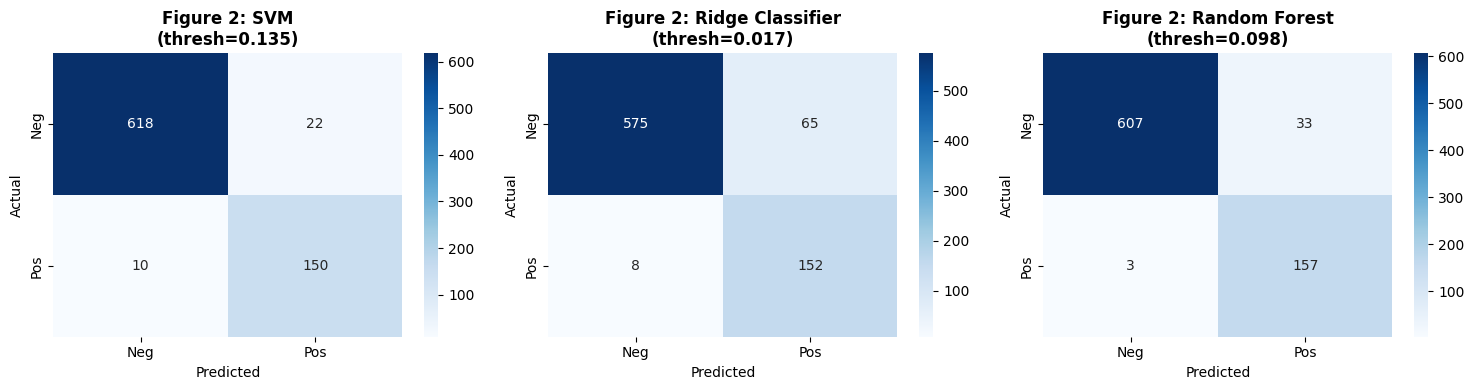

In [12]:
# Figure 2: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_data = [
    ('SVM', y_test, svm_test_proba, svm_thresh),
    ('Ridge Classifier', y_test, ridge_test_proba, ridge_thresh),
    ('Random Forest', y_test, rf_test_proba, rf_thresh),
]
for ax, (name, yt, yp, thresh) in zip(axes, model_data):
    y_pred = (yp >= thresh).astype(int)
    cm = confusion_matrix(yt, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    ax.set_title(f'Figure 2: {name}\n(thresh={thresh:.3f})', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('fig2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

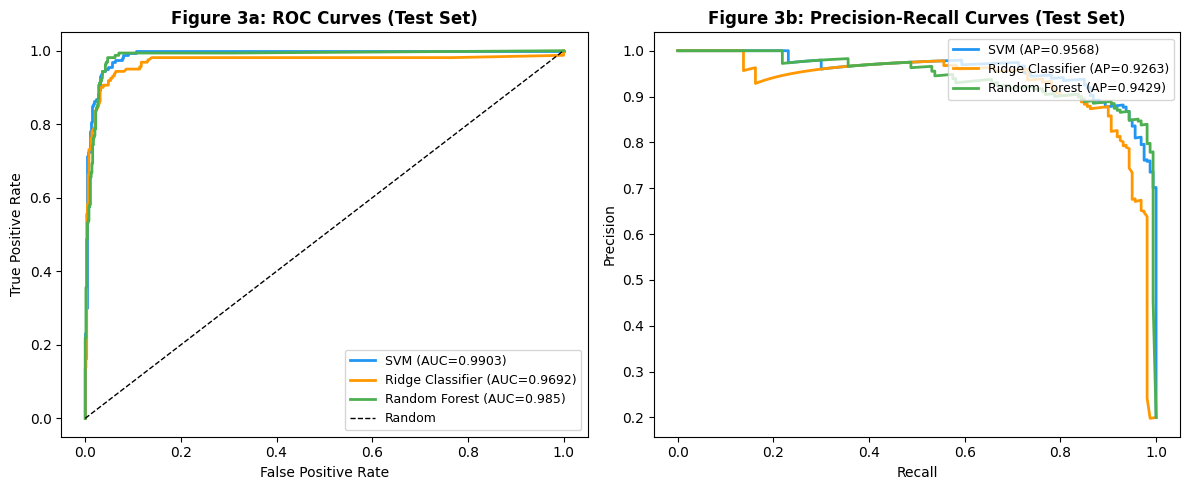

In [13]:
# Figure 3: ROC and PR curves
from sklearn.metrics import roc_curve, precision_recall_curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2196F3', '#FF9800', '#4CAF50']
model_names = ['SVM', 'Ridge Classifier', 'Random Forest']
probas      = [svm_test_proba, ridge_test_proba, rf_test_proba]
aucroc_vals = [svm_metrics['auc_roc'], ridge_metrics['auc_roc'], rf_metrics['auc_roc']]
prauc_vals  = [svm_metrics['pr_auc'],  ridge_metrics['pr_auc'],  rf_metrics['pr_auc']]

for c, name, prob, ar, ap in zip(colors, model_names, probas, aucroc_vals, prauc_vals):
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=c, label=f'{name} (AUC={ar})', lw=2)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, color=c, label=f'{name} (AP={ap})', lw=2)

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_title('Figure 3a: ROC Curves (Test Set)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)

axes[1].set_title('Figure 3b: Precision-Recall Curves (Test Set)', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

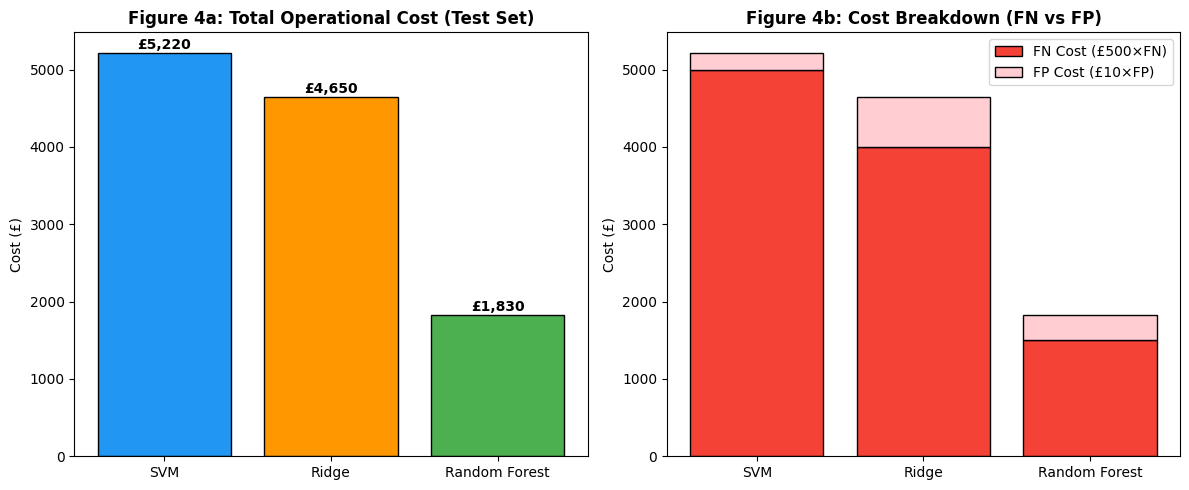


Champion Model: Random Forest
  Lowest total cost: £1,830
  Highest recall:    0.9812
  Only 3 missed failures (vs 10 SVM, 8 Ridge)


In [14]:
# Figure 4: Cost comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['SVM', 'Ridge', 'Random Forest']
total_costs  = [svm_metrics['total_cost'],  ridge_metrics['total_cost'],  rf_metrics['total_cost']]
fn_costs     = [svm_metrics['fn_cost'],     ridge_metrics['fn_cost'],     rf_metrics['fn_cost']]
fp_costs     = [svm_metrics['fp_cost'],     ridge_metrics['fp_cost'],     rf_metrics['fp_cost']]

x = np.arange(len(models))
bars = axes[0].bar(x, total_costs, color=['#2196F3','#FF9800','#4CAF50'], edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_title('Figure 4a: Total Operational Cost (Test Set)', fontweight='bold')
axes[0].set_ylabel('Cost (£)')
for bar, cost in zip(bars, total_costs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'£{cost:,}', ha='center', fontweight='bold')

# Stacked: FP vs FN
axes[1].bar(x, fn_costs,    label='FN Cost (£500×FN)', color='#F44336', edgecolor='black')
axes[1].bar(x, fp_costs, bottom=fn_costs, label='FP Cost (£10×FP)', color='#FFCDD2', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_title('Figure 4b: Cost Breakdown (FN vs FP)', fontweight='bold')
axes[1].set_ylabel('Cost (£)'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nChampion Model: Random Forest')
print(f'  Lowest total cost: £{rf_metrics["total_cost"]:,}')
print(f'  Highest recall:    {rf_metrics["recall"]}')
print(f'  Only {rf_metrics["fn"]} missed failures (vs {svm_metrics["fn"]} SVM, {ridge_metrics["fn"]} Ridge)')

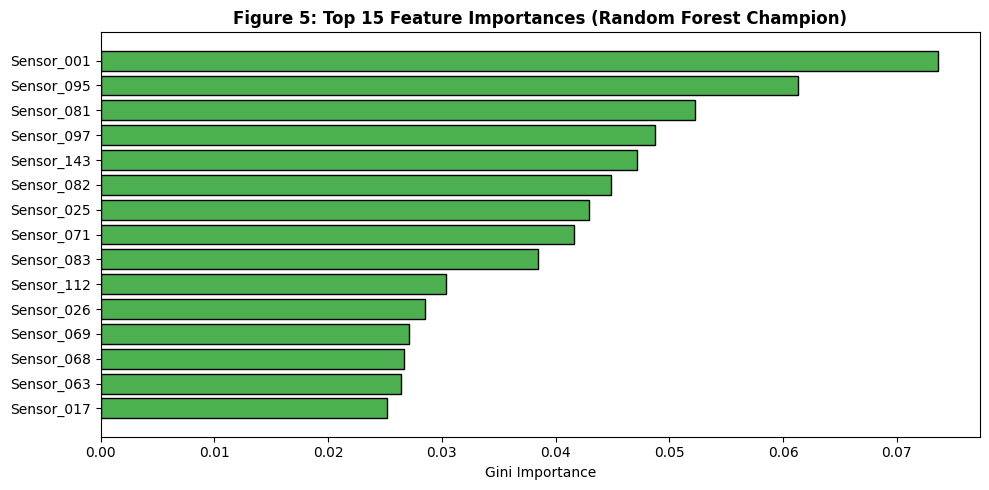

In [15]:
# Figure 5: Feature importance (Random Forest)
feature_names = X_train_full.columns.tolist()
importances   = rf_best.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([feature_names[i] for i in top_idx], importances[top_idx], color='#4CAF50', edgecolor='black')
ax.set_xlabel('Gini Importance')
ax.set_title(f'Figure 5: Top {top_n} Feature Importances (Random Forest Champion)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. AI Maintenance Agent

In [16]:
# Champion model: Random Forest
# Thresholds derived from validation data (NO test set involvement)
T_A2 = 0.50       # Immediate intervention
T_A1 = rf_thresh  # Scheduled inspection (cost-optimal threshold from validation)
# T_A0 = below T_A1 -> Continue monitoring

print(f'Agent decision thresholds (validation-derived):')
print(f'  A2 (Immediate):    p >= {T_A2}')
print(f'  A1 (Schedule):     {T_A1:.3f} <= p < {T_A2}')
print(f'  A0 (Monitor):      p < {T_A1:.3f}')

rf_op_proba = rf_best.predict_proba(X_op_sc)[:, 1]

agent_records = []
for i, p in enumerate(rf_op_proba):
    record_id = f'OP_{i+1:04d}'
    if p >= T_A2:
        action    = 'A2: Immediate Intervention'
        rationale = (f'High failure probability ({p:.3f} >= {T_A2}); '
                     f'safety escalation required — do not operate vehicle')
        exp_cost  = p * COST_FN
    elif p >= T_A1:
        action    = 'A1: Schedule Inspection'
        rationale = (f'Elevated failure probability ({p:.3f} >= {T_A1:.3f}); '
                     f'cost-optimal threshold exceeded — schedule within 24 hrs')
        exp_cost  = p * COST_FN + (1 - p) * COST_FP
    else:
        action    = 'A0: Continue Monitoring'
        rationale = (f'Low failure probability ({p:.3f} < {T_A1:.3f}); '
                     f'below intervention threshold — continue routine monitoring')
        exp_cost  = p * COST_FN
    agent_records.append({
        'record_id':           record_id,
        'model_score':         round(float(p), 4),
        'recommended_action':  action,
        'decision_rationale':  rationale,
        'expected_cost_gbp':   round(float(exp_cost), 2)
    })

agent_df = pd.DataFrame(agent_records)
print('\nAgent decision summary:')
print(agent_df['recommended_action'].value_counts())
print(f'\nTotal expected cost across operational feed: £{agent_df["expected_cost_gbp"].sum():.2f}')

# Save the required CSV
agent_df.to_csv('CSI_6_ARI_2526_CW2_AGENT_4438487.csv', index=False)
print('\nAgent CSV saved: CSI_6_ARI_2526_CW2_AGENT_4438487.csv')
agent_df.head(10)

Agent decision thresholds (validation-derived):
  A2 (Immediate):    p >= 0.5
  A1 (Schedule):     0.098 <= p < 0.5
  A0 (Monitor):      p < 0.098

Agent decision summary:
recommended_action
A0: Continue Monitoring       175
A1: Schedule Inspection        14
A2: Immediate Intervention     11
Name: count, dtype: int64

Total expected cost across operational feed: £6804.04

Agent CSV saved: CSI_6_ARI_2526_CW2_AGENT_4438487.csv


,record_id,model_score,recommended_action,decision_rationale,expected_cost_gbp
0,OP_0001,0.2479,A1: Schedule Inspection,Elevated failure probability (0.248 >= 0.098);...,131.49
1,OP_0002,0.0000,A0: Continue Monitoring,Low failure probability (0.000 < 0.098); below...,0.00
2,OP_0003,0.0000,A0: Continue Monitoring,Low failure probability (0.000 < 0.098); below...,0.00
3,OP_0004,0.0000,A0: Continue Monitoring,Low failure probability (0.000 < 0.098); below...,0.00
4,OP_0005,0.0000,A0: Continue Monitoring,Low failure probability (0.000 < 0.098); below...,0.00
5,OP_0006,0.1836,A1: Schedule Inspection,Elevated failure probability (0.184 >= 0.098);...,99.94
6,OP_0007,0.0000,A0: Continue Monitoring,Low failure probability (0.000 < 0.098); below...,0.00
7,OP_0008,0.7759,A2: Immediate Intervention,High failure probability (0.776 >= 0.5); safet...,387.96
8,OP_0009,0.1591,A1: Schedule Inspection,Elevated failure probability (0.159 >= 0.098);...,87.96
9,OP_0010,0.0000,A0: Continue Monitoring,Low failure probability (0.000 < 0.098); below...,0.00


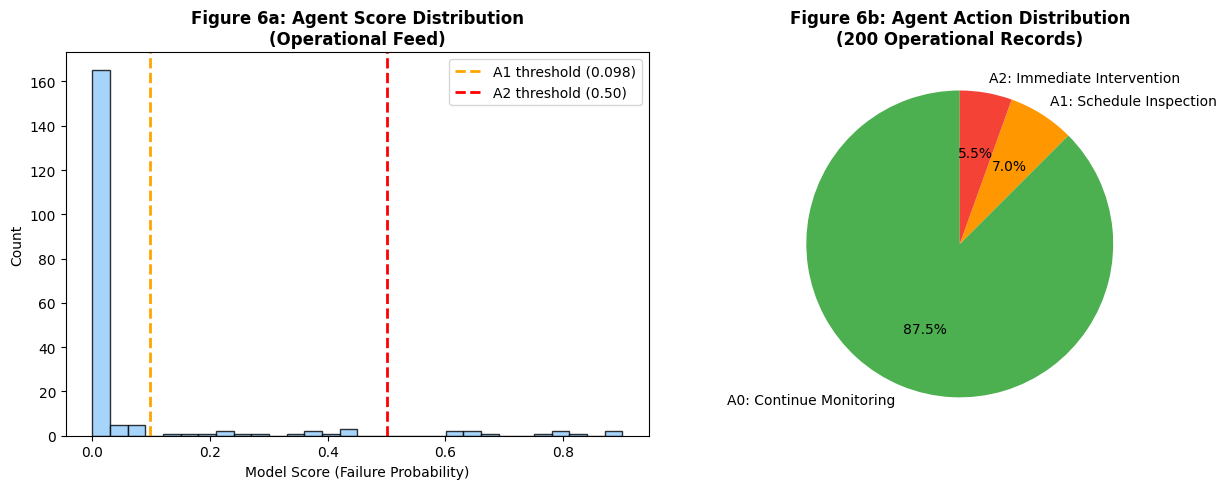

All outputs generated successfully.


In [17]:
# Figure 6: Agent score distribution & decision zones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Score histogram with thresholds
axes[0].hist(rf_op_proba, bins=30, color='#90CAF9', edgecolor='black', alpha=0.8)
axes[0].axvline(T_A1, color='orange', lw=2, linestyle='--', label=f'A1 threshold ({T_A1:.3f})')
axes[0].axvline(T_A2, color='red',    lw=2, linestyle='--', label=f'A2 threshold ({T_A2:.2f})')
axes[0].set_title('Figure 6a: Agent Score Distribution\n(Operational Feed)', fontweight='bold')
axes[0].set_xlabel('Model Score (Failure Probability)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Pie chart of actions
action_counts = agent_df['recommended_action'].value_counts()
axes[1].pie(action_counts, labels=action_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50','#FF9800','#F44336'], startangle=90)
axes[1].set_title('Figure 6b: Agent Action Distribution\n(200 Operational Records)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_agent_output.png', dpi=150, bbox_inches='tight')
plt.show()

print('All outputs generated successfully.')